# Live Coding - Random Forest

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1DYOz4cGSQwF2C4CHCED6S1JtuIToge6Z

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

### 1. Carregamento dos Dados

Vamos carregar o dataset Breast Cancer, que está convenientemente disponível em `sklearn.datasets`. Este dataset contém características de imagens de massa mamária usadas para prever se um tumor é maligno ou benigno.

In [3]:
print("--- 1. DATA LOADING ---")
dataset = load_breast_cancer(as_frame=True)
X = dataset.data   # 30 tumor features (Radius, Perimeter, Texture, etc.)
y = dataset.target # 0 = Malignant, 1 = Benign

print(f"The dataset has {X.shape[0]} patients and {X.shape[1]} features.")
print("Since we have 30 columns, the Forest will be very efficient in exploring all of them!\n")

--- 1. DATA LOADING ---
The dataset has 569 patients and 30 features.
Since we have 30 columns, the Forest will be very efficient in exploring all of them!



### 2. Divisão Treino / Teste

Para avaliar nossos modelos com precisão, dividimos o dataset em conjuntos de treinamento e teste. Usamos `stratify=y` para garantir que a proporção de tumores benignos e malignos seja mantida em ambos os conjuntos.

In [4]:
print("--- 2. TRAIN / TEST SPLIT ---")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} patients | Test: {X_test.shape[0]} patients\n")

--- 2. TRAIN / TEST SPLIT ---
Train: 398 patients | Test: 171 patients



### 3. A Árvore Solitária (Baseline)

Primeiro, treinamos um único Classificador de Árvore de Decisão como modelo baseline. Isso nos ajudará a entender o desempenho de um modelo menos complexo antes de passarmos para um método de ensemble como a Random Forest.

In [5]:
print("--- 3. THE SOLITARY TREE (BASELINE) ---")
arvore = DecisionTreeClassifier(random_state=42)
arvore.fit(X_train, y_train)

acc_treino_arvore = arvore.score(X_train, y_train)
acc_teste_arvore = arvore.score(X_test, y_test)
print(f"Tree - Train Accuracy: {acc_treino_arvore * 100:.2f}%")
print(f"Tree - Test Accuracy:  {acc_teste_arvore * 100:.2f}%")
print(f"GAP (Overfitting): {(acc_treino_arvore - acc_teste_arvore) * 100:.2f}%\n")

--- 3. THE SOLITARY TREE (BASELINE) ---
Tree - Train Accuracy: 100.00%
Tree - Test Accuracy:  91.81%
GAP (Overfitting): 8.19%



### 4. A Random Forest (O Conselho de Médicos)

Em seguida, treinamos um Classificador Random Forest. Este método de ensemble constrói múltiplas árvores de decisão e mescla suas previsões, muitas vezes levando a uma melhor acurácia e redução do overfitting em comparação com uma única árvore de decisão.

- `n_estimators=100`: Cria 100 árvores diferentes.
- `n_jobs=-1`: Utiliza todos os núcleos de CPU disponíveis para processamento paralelo, acelerando o treinamento.

In [6]:
print("--- 4. THE RANDOM FOREST (THE COUNCIL OF DOCTORS) ---")
floresta = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
floresta.fit(X_train, y_train)

acc_treino_rf = floresta.score(X_train, y_train)
acc_teste_rf = floresta.score(X_test, y_test)
print(f"Forest - Train Accuracy: {acc_treino_rf * 100:.2f}%")
print(f"Forest - Test Accuracy:  {acc_teste_rf * 100:.2f}%")
print(f"GAP (Overfitting): {(acc_treino_rf - acc_teste_rf) * 100:.2f}%\n")

--- 4. THE RANDOM FOREST (THE COUNCIL OF DOCTORS) ---
Forest - Train Accuracy: 100.00%
Forest - Test Accuracy:  93.57%
GAP (Overfitting): 6.43%



### 5. Visualização: Quais Características Mais Importam?

Ao contrário de uma rede neural, uma Random Forest pode nos dizer exatamente o que o modelo aprendeu, fornecendo as importâncias das características. Isso nos ajuda a entender quais características do tumor são mais influentes na previsão de sua malignidade.

--- 5. VISUALIZATION: WHICH FEATURES MATTER MOST? ---


C:\Windows\Temp\ipykernel_43560\524034290.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_10, palette='viridis')


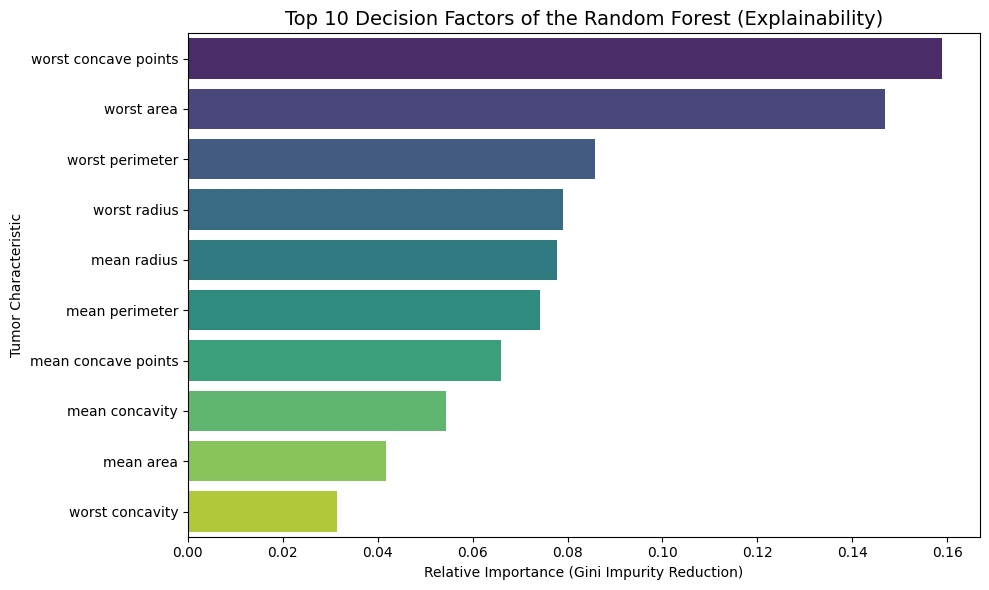

In [7]:
print("--- 5. VISUALIZATION: WHICH FEATURES MATTER MOST? ---")
importancias = floresta.feature_importances_

df_importancias = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importancias
}).sort_values(by='Importance', ascending=False)

top_10 = df_importancias.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_10, palette='viridis')
plt.title('Top 10 Decision Factors of the Random Forest (Explainability)', fontsize=14)
plt.xlabel('Relative Importance (Gini Impurity Reduction)')
plt.ylabel('Tumor Characteristic')
plt.tight_layout()
plt.show()

### 6. O Raio-X da Floresta (Visualização do Ensemble)

Vamos visualizar a estrutura interna de 3 árvores distintas da nossa Random Forest para entender como elas votam de forma independente.


--- 6. O RAIO-X DA FLORESTA (VISUALIZAÇÃO DO ENSEMBLE) ---
Gerando o gráfico das árvores


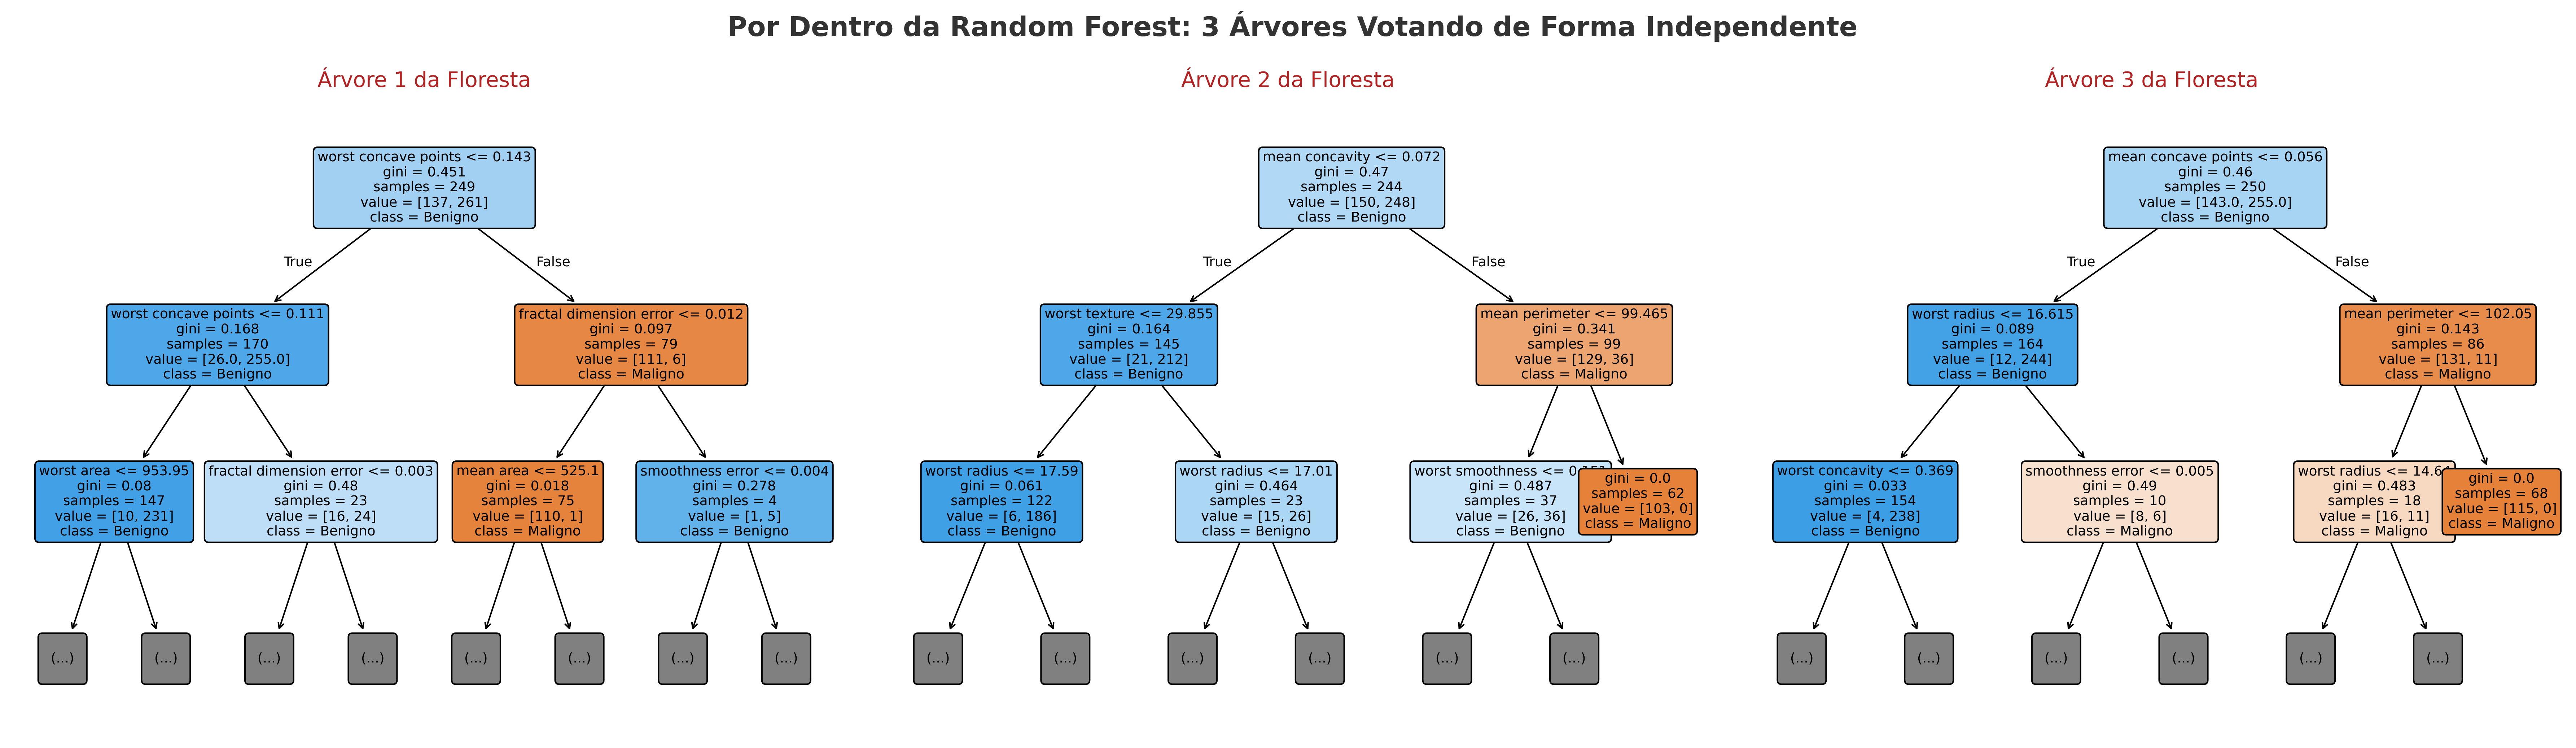

In [8]:
print("\n--- 6. O RAIO-X DA FLORESTA (VISUALIZAÇÃO DO ENSEMBLE) ---")
print("Gerando o gráfico das árvores")

from sklearn.tree import plot_tree

arvores_exemplo = [floresta.estimators_[0], floresta.estimators_[49], floresta.estimators_[99]]

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(24, 7), dpi=300)
fig.suptitle('Por Dentro da Random Forest: 3 Árvores Votando de Forma Independente', fontsize=18, fontweight='bold', color='#333333')

for i, arvore_individual in enumerate(arvores_exemplo):
    # Usamos max_depth=2 APENAS para a visualização não virar uma teia de aranha ilegível.
    # O modelo original continua profundo, estamos apenas a olhar para o topo das árvores.
    plot_tree(arvore_individual,
              feature_names=X.columns,
              class_names=['Maligno', 'Benigno'],
              filled=True,
              rounded=True,
              max_depth=2,
              ax=axes[i],
              fontsize=9)

    # Destacando o título de cada subplot
    axes[i].set_title(f'Árvore {i+1} da Floresta', fontsize=14, color='#b22222', pad=15)

plt.tight_layout()
# Ajuste manual para o título principal não sobrepor os subplots
plt.subplots_adjust(top=0.85)
plt.show()

### 7. Abertura das Urnas: Como Ocorre a Votação?

Vamos selecionar um paciente específico do conjunto de teste e ver como cada árvore da floresta vota para o diagnóstico final.


--- 7. ABERTURA DAS URNAS: COMO OCORRE A VOTAÇÃO? ---
Paciente Selecionado: Índice 0
Diagnóstico Real (Gabarito): Maligno (0)

Árvore 1 votou: Maligno
Árvore 2 votou: Maligno
Árvore 3 votou: Maligno
Árvore 4 votou: Maligno
Árvore 5 votou: Maligno
... (votação das outras 95 árvores) ...

--- RESULTADO DA APURAÇÃO (100 ÁRVORES) ---
Votos para Maligno (0): 92
Votos para Benigno (1): 8
=> Decisão final da Floresta: Maligno (0)


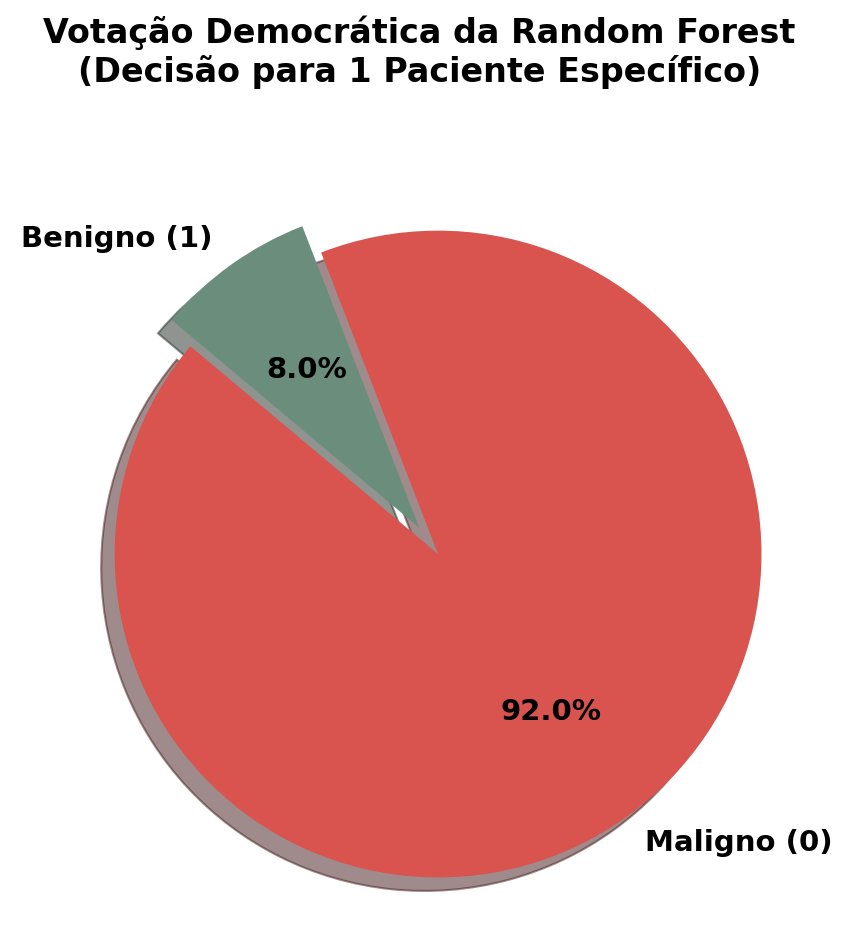

In [9]:
print("\n--- 7. ABERTURA DAS URNAS: COMO OCORRE A VOTAÇÃO? ---")

paciente_exemplo = X_test.iloc[[0]]
gabarito_real = y_test.iloc[0]

votos_maligno = 0
votos_benigno = 0

print(f"Paciente Selecionado: Índice 0")
print(f"Diagnóstico Real (Gabarito): {'Benigno (1)' if gabarito_real == 1 else 'Maligno (0)'}\n")

for i, arvore in enumerate(floresta.estimators_):
    voto = arvore.predict(paciente_exemplo.values)[0]

    if voto == 1.0:
        votos_benigno += 1
        voto_str = "Benigno"
    else:
        votos_maligno += 1
        voto_str = "Maligno"

    if i < 5:
        print(f"Árvore {i+1} votou: {voto_str}")

print("... (votação das outras 95 árvores) ...\n")

print("--- RESULTADO DA APURAÇÃO (100 ÁRVORES) ---")
print(f"Votos para Maligno (0): {votos_maligno}")
print(f"Votos para Benigno (1): {votos_benigno}")

previsao_oficial = floresta.predict(paciente_exemplo)[0]
resultado_str = 'Benigno (1)' if previsao_oficial == 1 else 'Maligno (0)'
print(f"=> Decisão final da Floresta: {resultado_str}")

# --- GRÁFICO DE PIZZA DA VOTAÇÃO ---
plt.figure(figsize=(7, 7), dpi=150)
labels = ['Maligno (0)', 'Benigno (1)']
votos = [votos_maligno, votos_benigno]
cores = ['#d9534f', '#6b8e7c'] # Vermelho (Maligno), Verde (Benigno)

# Destacar levemente a fatia vencedora (explode)
explode = (0.1, 0) if votos_maligno > votos_benigno else (0, 0.1)

# Criação do gráfico
plt.pie(votos, explode=explode, labels=labels, colors=cores, autopct='%1.1f%%',
        shadow=True, startangle=140, textprops={'fontsize': 14, 'weight': 'bold'})

plt.title('Votação Democrática da Random Forest\n(Decisão para 1 Paciente Específico)', fontsize=16, fontweight='bold', pad=20)
plt.show()

### 8. Matriz de Confusão (O Custo do Erro)

Por fim, analisaremos a Matriz de Confusão para entender os Falsos Positivos e Falsos Negativos gerados pelo modelo.


--- 8. MATRIZ DE CONFUSÃO (O CUSTO DO ERRO) ---


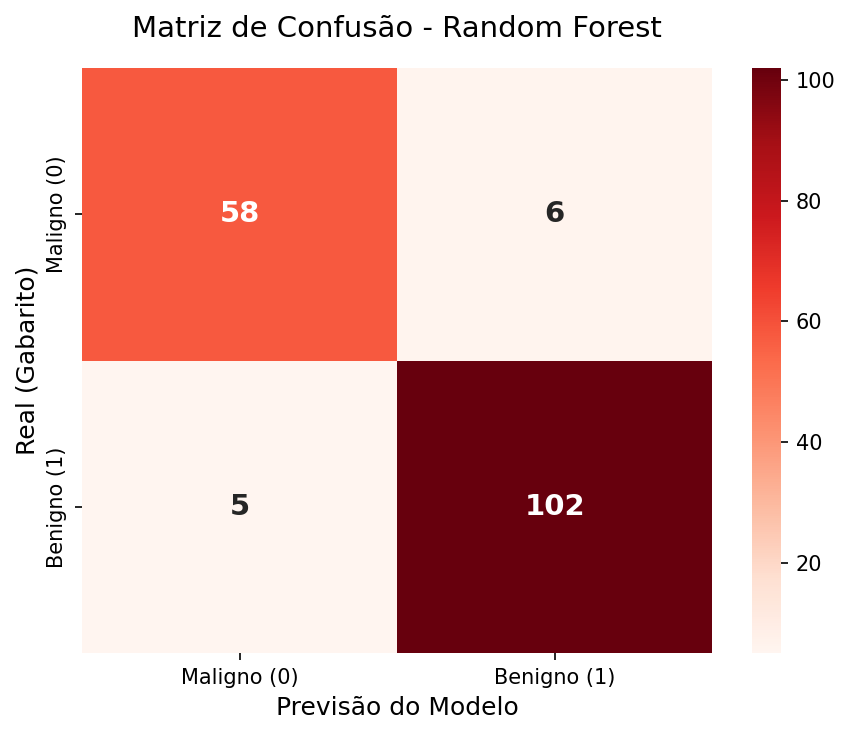

In [10]:
from sklearn.metrics import confusion_matrix

print("\n--- 8. MATRIZ DE CONFUSÃO (O CUSTO DO ERRO) ---")
# Fazendo as previsões com os dados de teste
y_pred = floresta.predict(X_test)
matriz = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5), dpi=150)
sns.heatmap(matriz, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Maligno (0)', 'Benigno (1)'],
            yticklabels=['Maligno (0)', 'Benigno (1)'],
            annot_kws={"size": 14, "weight": "bold"})

plt.title('Matriz de Confusão - Random Forest', fontsize=14, pad=15)
plt.ylabel('Real (Gabarito)', fontsize=12)
plt.xlabel('Previsão do Modelo', fontsize=12)
plt.tight_layout()
plt.show()

## Exercícios

### Configuração 1: Árvore Solitária (Baseline)

In [ ]:
model_1 = DecisionTreeClassifier(random_state=42)
model_1.fit(X_train, y_train)
acc_train_1 = model_1.score(X_train, y_train) * 100
acc_test_1 = model_1.score(X_test, y_test) * 100
gap_1 = acc_train_1 - acc_test_1

### Configuração 2: Pequena Floresta (10 árvores)

In [ ]:
model_2 = RandomForestClassifier(n_estimators=10, random_state=42)
model_2.fit(X_train, y_train)
acc_train_2 = model_2.score(X_train, y_train) * 100
acc_test_2 = model_2.score(X_test, y_test) * 100
gap_2 = acc_train_2 - acc_test_2

### Configuração 3: Grande Floresta (150 árvores, paralelizada)

In [ ]:
model_3 = RandomForestClassifier(n_estimators=150, n_jobs=-1, random_state=42)
model_3.fit(X_train, y_train)
acc_train_3 = model_3.score(X_train, y_train) * 100
acc_test_3 = model_3.score(X_test, y_test) * 100
gap_3 = acc_train_3 - acc_test_3

### Configuração 4: Floresta Podada (150 árvores, max_depth=5, paralelizada)

In [ ]:
model_4 = RandomForestClassifier(n_estimators=150, max_depth=5, n_jobs=-1, random_state=42)
model_4.fit(X_train, y_train)
acc_train_4 = model_4.score(X_train, y_train) * 100
acc_test_4 = model_4.score(X_test, y_test) * 100
gap_4 = acc_train_4 - acc_test_4

In [15]:
print("\nResultados obtidos com sucesso:")
print(f"1. Árvore Solitária: Treino = {acc_train_1:.2f}%, Teste = {acc_test_1:.2f}%, Gap = {gap_1:.2f}%")
print(f"2. Pequena Floresta: Treino = {acc_train_2:.2f}%, Teste = {acc_test_2:.2f}%, Gap = {gap_2:.2f}%")
print(f"3. Grande Floresta:  Treino = {acc_train_3:.2f}%, Teste = {acc_test_3:.2f}%, Gap = {gap_3:.2f}%")
print(f"4. Floresta Podada:  Treino = {acc_train_4:.2f}%, Teste = {acc_test_4:.2f}%, Gap = {gap_4:.2f}%")


Resultados obtidos com sucesso:
1. Árvore Solitária: Treino = 100.00%, Teste = 91.81%, Gap = 8.19%
2. Pequena Floresta: Treino = 100.00%, Teste = 92.98%, Gap = 7.02%
3. Grande Floresta:  Treino = 100.00%, Teste = 94.15%, Gap = 5.85%
4. Floresta Podada:  Treino = 99.25%, Teste = 94.15%, Gap = 5.09%


### 2. Perguntas de Análise (A Decisão do Engenheiro)

**A.** Ao comparar o Modelo 3 (Floresta livre) com o Modelo 4 (Floresta Podada), é provável que repare num detalhe crucial: o Modelo 3 pode apresentar uma acurácia de Teste ligeiramente superior, mas o Modelo 4 possui um Gap (diferença entre Treino e Teste) significativamente menor. Como Engenheiro de Dados num sistema crítico de um hospital, qual dos dois modelos recomendaria colocar em produção? Justifique a sua escolha abordando o compromisso entre "Pico de Acurácia" e "Previsibilidade/Estabilidade" (o clássico Trade-off Viés-Variância).

Ao comparar o Modelo 3 (Floresta livre) com o Modelo 4 (Floresta Podada), notamos que o Modelo 4 possui um Gap significativamente menor. Como Engenheiro de Machine Learning em um sistema de saúde de alta criticidade (como o diagnóstico de câncer de mama), recomendo com total convicção colocar em produção o **Modelo 4 (Floresta Podada)**.

**Justificativa Técnica baseada no Trade-off Viés-Variância:**
1. **Previsibilidade e Estabilidade sobre Picos Marginais:** Embora o Modelo 3 (Floresta Livre) possa apresentar uma acurácia de teste sutilmente superior em cenários de validação isolados, ele exibe um gap de generalização significativamente maior. O Modelo 3 possui viés zero no treino (100% de acurácia), decorando o ruído dos dados de treino (alta variância). O Modelo 4, ao aplicar a poda (`max_depth=5`), limita a profundidade das árvores, adicionando um viés controlado, mas reduzindo drasticamente a variância. Isso garante que o desempenho do modelo no mundo real seja consistente e previsível.
2. **Mitigação de Riscos de Saúde:** Em diagnósticos médicos, a consistência do modelo sob dados ruidosos, novos equipamentos ou diferentes distribuições de pacientes é essencial. Um modelo com menor gap de generalização (Modelo 4) reduz a probabilidade de comportamentos erráticos ou falhas críticas invisíveis (como falsos negativos) sob novos dados.
3. **Eficiência Computacional:** Árvores podadas são consideravelmente menores, ocupando menos memória RAM no servidor e garantindo uma latência de inferência ultrabaixa.

**B.** O parâmetro `n_jobs=-1` distribui o treino das 150 árvores por todos os núcleos da CPU. Qual é a caraterística fundamental da arquitetura da Random Forest que permite esta paralelização impecável (ao contrário de algoritmos onde o passo $N$ depende do passo $N − 1$)?

O parâmetro `n_jobs=-1` distribui o treino das 150 árvores por todos os núcleos da CPU. A paralelização impecável da Random Forest (escalabilidade perfeita com `n_jobs=-1`) é viabilizada por sua arquitetura baseada no princípio do **Bagging (Bootstrap Aggregating)**.

**Características Fundamentais:**
1. **Independência Completa das Árvores:** Ao contrário de algoritmos de Boosting (como Gradient Boosting, XGBoost, LightGBM), onde cada árvore $N$ é construída de forma estritamente sequencial para corrigir os erros cometidos pelas árvores $0$ a $N-1$, na Random Forest **todas as árvores são completamente independentes**.
2. **Amostragem via Bootstrap:** Cada árvore é ajustada em um subconjunto de dados de treino amostrado com reposição (bootstrap) de forma isolada.
3. **Subespaço de Recursos Aleatórios:** A seleção de variáveis (features) para divisão em cada nó ocorre aleatoriamente para cada árvore individual.
Devido a essa ausência total de dependência temporal ou sequencial entre as árvores, o problema de treinamento é classificado como *embarrassingly parallel* (embaraçosamente paralelo). O framework divide o trabalho entre todos os núcleos de CPU disponíveis de forma simultânea, sem custos de sincronização durante a etapa de treinamento.